<a href="https://colab.research.google.com/github/Paulo83-dev/mestrado-computacao-aplicada/blob/main/C%C3%B3pia_de_aula02a_perceptron_learning_algorithm_with_bias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Geração do Conjunto de Dados
Este bloco define uma função para criar dados sintéticos linearmente separáveis. Ele gera pontos aleatórios em 2D e os rotula como `1` ou `-1` baseando-se na sua posição em relação a uma reta definida por coeficientes e um intercepto.

In [ ]:
import numpy as np

def createDataset(n=20):
  X = np.random.rand(n,2)
  coefs = np.array([1, 1])
  intercept = 1
  labels = X @ coefs - intercept
  y = np.array(labels>0, dtype=int)*2-1
  return X, y

X, y = createDataset()
print(X)
print(y)

[[4.21596407e-01 5.91017757e-01]
 [8.02535949e-01 1.78359176e-02]
 [8.48359418e-01 9.08255997e-01]
 [6.12266710e-01 5.80813104e-04]
 [5.41617923e-02 9.79743193e-01]
 [6.36792009e-01 2.15698085e-01]
 [5.75150513e-01 1.96201226e-01]
 [1.70950823e-01 6.55515518e-01]
 [8.41931111e-01 5.61132943e-01]
 [3.26851087e-01 1.27872640e-01]
 [6.33559280e-01 5.00364706e-01]
 [4.33106455e-01 9.23049551e-02]
 [6.42713346e-01 1.20209689e-01]
 [6.44620325e-01 7.40765946e-01]
 [8.80659056e-01 4.48987500e-02]
 [6.78619357e-01 1.23452196e-01]
 [3.27871961e-02 2.23947147e-02]
 [6.99599684e-01 5.34027941e-01]
 [6.39354292e-01 4.15465197e-01]
 [4.95694973e-01 8.65610251e-01]]
[ 1 -1  1 -1  1 -1 -1 -1  1 -1  1 -1 -1  1 -1 -1 -1  1  1  1]


### 2. Funções de Visualização
Aqui definimos funções auxiliares usando `matplotlib` para visualizar os pontos gerados (coloridos por classe) e para desenhar o hiperplano (a linha de decisão) no gráfico.

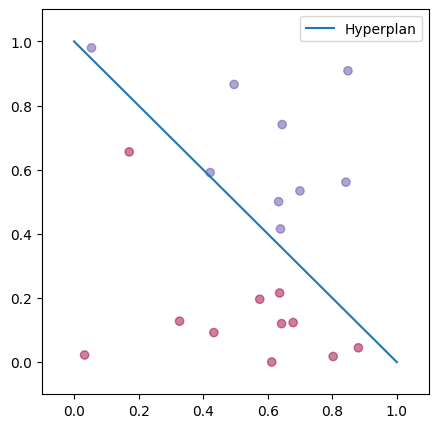

In [ ]:
import matplotlib.pyplot as plt

def plotDataset(X, y):
  plt.figure(figsize=(5,5))
  plt.scatter(X[:,0], X[:,1], c=y, cmap="Spectral", alpha=0.5)
  plt.xlim(-0.1,1.1)
  plt.ylim(-0.1,1.1)

def plotHyperplan(vector, intercept, legend="Hyperplan"):
  xs = np.array([0,1])
  ys = -(vector[0]*xs + intercept)/vector[1]
  plt.plot(xs, ys, label=legend)
  plt.legend()

plotDataset(X, y)
plotHyperplan(np.array([1, 1]), -1)
plt.show()

### 3. Implementação do PLA (Sem Bias)
Esta é uma implementação inicial do *Perceptron Learning Algorithm*. Note que, nesta versão, o algoritmo tenta encontrar os pesos `w` mas não considera um termo de viés (*bias*), o que pode dificultar a convergência se a reta ideal não passar pela origem.

Accuracy: 0.9
Weights: [-1.19743116  2.78419965]


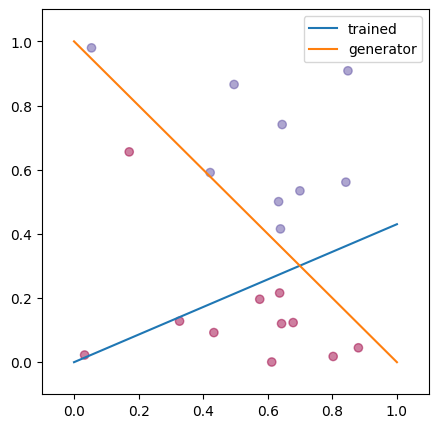

In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

class PLA(BaseEstimator, ClassifierMixin):
  def __init__(self, max_iter=10):
    self.max_iter = max_iter

  def fit(self, X, y):
    self.w_ = np.random.rand(X.shape[1])
    # PLA - Perceptron Learning Algoritm (without bias)
    for _ in range(self.max_iter):
      cost = 0
      idx = np.arange(X.shape[0])
      np.random.shuffle(idx)
      for i in idx:
        logits = X[i] @ self.w_
        y_pred = np.sign(logits)
        error = y[i] - y_pred
        if error != 0:
          cost += error**2
          self.w_ += error*X[i]
        if cost == 0:
          break
    return self

  def predict(self, X):
    logits = X @ self.w_
    y_pred = np.sign(logits)
    return y_pred

clf = PLA()
clf.fit(X, y)
y_pred = clf.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
print(f"Weights: {clf.w_}")
plotDataset(X, y)
plotHyperplan(clf.w_, 0, legend="trained")
plotHyperplan(np.array([1, 1]), -1, legend="generator")
plt.show()

### 4. Implementação do PLA (Com Bias)
Esta versão aprimorada do PLA inclui o termo de `bias`. Isso permite que a linha de decisão se desloque livremente pelo plano, aumentando drasticamente a probabilidade de alcançar 100% de acurácia em dados linearmente separáveis.

Accuracy: 1.0
Weights: [ 7.88590671 12.2549143 ], Bias: -9.945449477702288


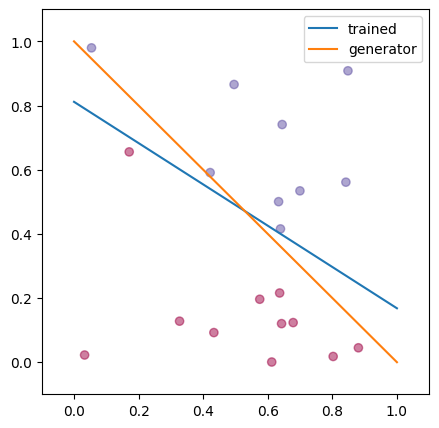

In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

class PLA(BaseEstimator, ClassifierMixin):
  def __init__(self, max_iter=1000):
    self.max_iter = max_iter

  def fit(self, X, y):
    self.w_ = np.random.rand(X.shape[1])
    self.b_ = np.random.rand()
    # PLA - Perceptron Learning Algoritm (without bias)
    for _ in range(self.max_iter):
      cost = 0
      idx = np.arange(X.shape[0])
      np.random.shuffle(idx)
      for i in idx:
        logits = X[i] @ self.w_ + self.b_
        y_pred = np.sign(logits)
        error = y[i] - y_pred
        if error != 0:
          cost += error**2
          self.w_ += error*X[i]
          self.b_ += error
        if cost == 0:
          break
    return self

  def predict(self, X):
    logits = X @ self.w_ + self.b_
    y_pred = np.sign(logits)
    return y_pred

clf = PLA()
clf.fit(X, y)
y_pred = clf.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
print(f"Weights: {clf.w_}, Bias: {clf.b_}")
plotDataset(X, y)
plotHyperplan(clf.w_, clf.b_, legend="trained")
plotHyperplan(np.array([1, 1]), -1, legend="generator")
plt.show()

### 5. Teste em Novos Dados
Por fim, testamos o modelo treinado em um conjunto de dados maior (200 pontos) para verificar sua capacidade de generalização e comparar a reta aprendida com a reta geradora original.

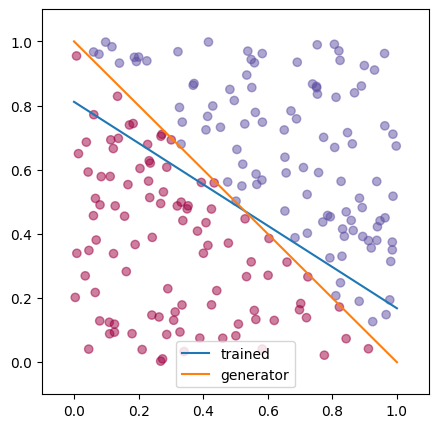

In [ ]:
X_test, y_test = createDataset(200)
plotDataset(X_test, y_test)
plotHyperplan(clf.w_, clf.b_, legend="trained")
plotHyperplan(np.array([1, 1]), -1, legend="generator")
plt.show()